# Fintech Retention Analysis

### 1. Retention & engagement diagnosis
- **H3**: New cohorts (recent `first_active_month`) show a steeper early drop-off than older cohorts — an "onboarding/activation risk" story, directly relevant to a growth team worried about new-user retention curves. --> Tested on Fintech Cohort Analysis Notebook

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,skew
from scipy import stats
import datetime as dt
%matplotlib inline

In [5]:
!pip list

Package                           Version
--------------------------------- ------------------
absl-py                           2.3.1
aext-assistant                    4.0.15
aext-assistant-server             4.0.15
aext-core                         4.0.15
aext-core-server                  4.0.15
aext-panels                       4.0.15
aext-panels-server                4.0.15
aext-share-notebook               4.0.15
aext-share-notebook-server        4.0.15
aext-shared                       4.0.15
agate                             1.9.1
aiobotocore                       2.12.3
aiohttp                           3.9.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.0
anaconda-proj

In [6]:
new = pd.read_csv('new_merchant_transactions.csv')
historical = pd.read_csv('historical_transactions.csv')
merchants = pd.read_csv('merchants.csv')

In [7]:
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


In [8]:
historical.groupby('card_id').authorized_flag.count().sort_values(ascending=False)

card_id
C_ID_3d3dfdc692    5582
C_ID_0cd2ce025c    2912
C_ID_cc3d4cd4e3    2143
C_ID_5ccc07beb9    2066
C_ID_5ea401d358    1786
                   ... 
C_ID_22df161ffe       2
C_ID_edc21e1571       2
C_ID_1e3c6b4f44       2
C_ID_112832329d       2
C_ID_cb5d101ac5       2
Name: authorized_flag, Length: 325540, dtype: int64

In [9]:
historical['authorized_flag'].value_counts()

authorized_flag
Y    26595452
N     2516909
Name: count, dtype: int64

In [10]:
new.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_415bb3a509,107,N,1,B,307,M_ID_b0c793002c,1,-0.557574,2018-03-11 14:57:36,1.0,9,19
1,Y,C_ID_415bb3a509,140,N,1,B,307,M_ID_88920c89e8,1,-0.569580,2018-03-19 18:53:37,1.0,9,19
2,Y,C_ID_415bb3a509,330,N,1,B,507,M_ID_ad5237ef6b,2,-0.551037,2018-04-26 14:08:44,1.0,9,14
3,Y,C_ID_415bb3a509,-1,Y,1,B,661,M_ID_9e84cda3b1,1,-0.671925,2018-03-07 09:43:21,NaN,-1,8
4,Y,C_ID_ef55cf8d4b,-1,Y,1,B,166,M_ID_3c86fa3831,1,-0.659904,2018-03-22 21:07:53,NaN,-1,29


In [11]:
# Concatenate two datasets
transactions = pd.concat(
    [historical, new],
    ignore_index=True
)

In [12]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31075392 entries, 0 to 31075391
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   authorized_flag       object 
 1   card_id               object 
 2   city_id               int64  
 3   category_1            object 
 4   installments          int64  
 5   category_3            object 
 6   merchant_category_id  int64  
 7   merchant_id           object 
 8   month_lag             int64  
 9   purchase_amount       float64
 10  purchase_date         object 
 11  category_2            float64
 12  state_id              int64  
 13  subsector_id          int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 3.2+ GB


In [13]:
transactions['card_id'].nunique()

325540

In [14]:
historical['card_id'].nunique()

325540

In [15]:
new['card_id'].nunique()

290001

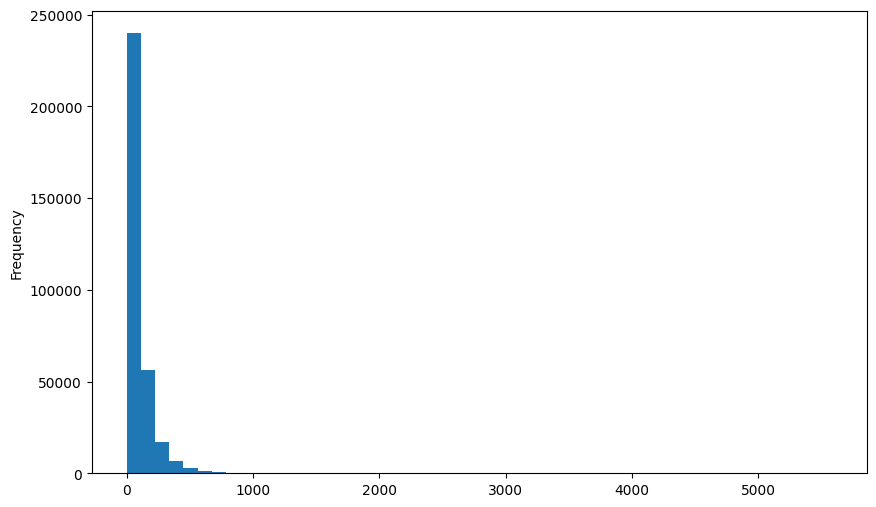

In [16]:
transaction_counts = (
    transactions.groupby('card_id')['authorized_flag']
    .count()
)

transaction_counts.plot(
    kind='hist',
    bins=50,
    figsize=(10, 6)
)
plt.show()

In [17]:
# purchase_date
print(f"Earliest date:", transactions['purchase_date'].min())
print(f"Latest date:", transactions['purchase_date'].max())

Earliest date: 2017-01-01 00:00:08
Latest date: 2018-04-30 23:59:59


## Cohort Analysis
--> create a monthly cohort based on the cardholders' first transaction month
- Only use historical dataset here as new merchant dataset does not contain all the transactions for all teh card_id with existing merchants

In [19]:
# 1. Create the transaction month
historical['purchase_date'] = pd.to_datetime(historical['purchase_date'])

historical['purchase_month'] = (
    historical['purchase_date'].dt.to_period('M')
)
historical['purchase_month'].head()

0    2017-06
1    2017-07
2    2017-08
3    2017-09
4    2017-03
Name: purchase_month, dtype: period[M]

In [20]:
# 2. Assign each card to its acquisition cohort
cohort = (
    historical.groupby('card_id')['purchase_month']
    .min()
    .rename('cohort_month')
)
cohort.head()

card_id
C_ID_00007093c1    2017-02
C_ID_0001238066    2017-09
C_ID_0001506ef0    2017-01
C_ID_0001793786    2017-01
C_ID_000183fdda    2017-08
Name: cohort_month, dtype: period[M]

In [21]:
# cohort is a series so map to the historical here
historical['cohort_month'] = historical['card_id'].map(cohort)
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,purchase_month,cohort_month
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37,2017-06,2017-01
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16,2017-07,2017-01
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37,2017-08,2017-01
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34,2017-09,2017-01
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37,2017-03,2017-01


In [22]:
# 3. Calculate the customer's month number
# Now calculate how many months after acquisition each transaction occurred.
historical['month_number'] = (
    (historical['purchase_month'].dt.year - historical['cohort_month'].dt.year) * 12
    + (historical['purchase_month'].dt.month - historical['cohort_month'].dt.month)
)
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,purchase_month,cohort_month,month_number
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37,2017-06,2017-01,5
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16,2017-07,2017-01,6
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37,2017-08,2017-01,7
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34,2017-09,2017-01,8
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37,2017-03,2017-01,2


In [23]:
# 4. Create the cohort retention table
cohort_data = (
    historical
    .groupby(['cohort_month', 'month_number'])['card_id']
    .nunique()
    .reset_index()
)
cohort_data.head()

,cohort_month,month_number,card_id
0,2017-01,0,111184
1,2017-01,1,97808
2,2017-01,2,98040
3,2017-01,3,94086
4,2017-01,4,91256


In [24]:
# then pivot
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='month_number',
    values='card_id'
)
cohort_table

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,,
2017-01,111184.0,97808.0,98040.0,94086.0,91256.0,88119.0,86732.0,83866.0,80698.0,77783.0,75719.0,73735.0,67477.0,60086.0
2017-02,23157.0,18672.0,18015.0,17663.0,17146.0,17149.0,16714.0,16379.0,15642.0,15295.0,14985.0,13380.0,11747.0,NaN
2017-03,17816.0,14236.0,14099.0,13876.0,13643.0,13360.0,12867.0,12376.0,12196.0,11850.0,10569.0,9262.0,NaN,NaN
2017-04,16405.0,13597.0,13441.0,13421.0,13083.0,12597.0,12147.0,11899.0,11470.0,10262.0,8999.0,NaN,NaN,NaN
2017-05,16224.0,13768.0,13857.0,13596.0,13112.0,12601.0,12272.0,11835.0,10726.0,9485.0,NaN,NaN,NaN,NaN
2017-06,17024.0,14928.0,14887.0,14522.0,13960.0,13585.0,13111.0,11906.0,10510.0,NaN,NaN,NaN,NaN,NaN
2017-07,20361.0,18098.0,17999.0,17428.0,17076.0,16551.0,15040.0,13211.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-08,22309.0,20288.0,20061.0,19749.0,19075.0,17347.0,15383.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09,22780.0,20905.0,21011.0,20618.0,18933.0,16724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# 5. Convert it to retention %
retention_table = cohort_table.div(
    cohort_table.iloc[:, 0],
    axis=0
)
retention_table = retention_table * 100
retention_table

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,,
2017-01,100.0,87.969492,88.178155,84.621888,82.076558,79.255109,78.007627,75.429918,72.580587,69.958807,68.102425,66.317995,60.689488,54.041948
2017-02,100.0,80.632206,77.795051,76.274992,74.042406,74.055361,72.176880,70.730233,67.547610,66.049143,64.710455,57.779505,50.727642,NaN
2017-03,100.0,79.905703,79.136731,77.885047,76.577234,74.988774,72.221599,69.465649,68.455321,66.513247,59.323080,51.986978,NaN,NaN
2017-04,100.0,82.883267,81.932338,81.810424,79.750076,76.787565,74.044499,72.532764,69.917708,62.554099,54.855227,NaN,NaN,NaN
2017-05,100.0,84.861933,85.410503,83.801775,80.818540,77.668886,75.641026,72.947485,66.111933,58.462771,NaN,NaN,NaN,NaN
2017-06,100.0,87.687970,87.447133,85.303102,82.001880,79.799107,77.014803,69.936560,61.736372,NaN,NaN,NaN,NaN,NaN
2017-07,100.0,88.885615,88.399391,85.595010,83.866215,81.287756,73.866706,64.883847,NaN,NaN,NaN,NaN,NaN,NaN
2017-08,100.0,90.940876,89.923349,88.524811,85.503608,77.757856,68.954234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09,100.0,91.769096,92.234416,90.509219,83.112379,73.415277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


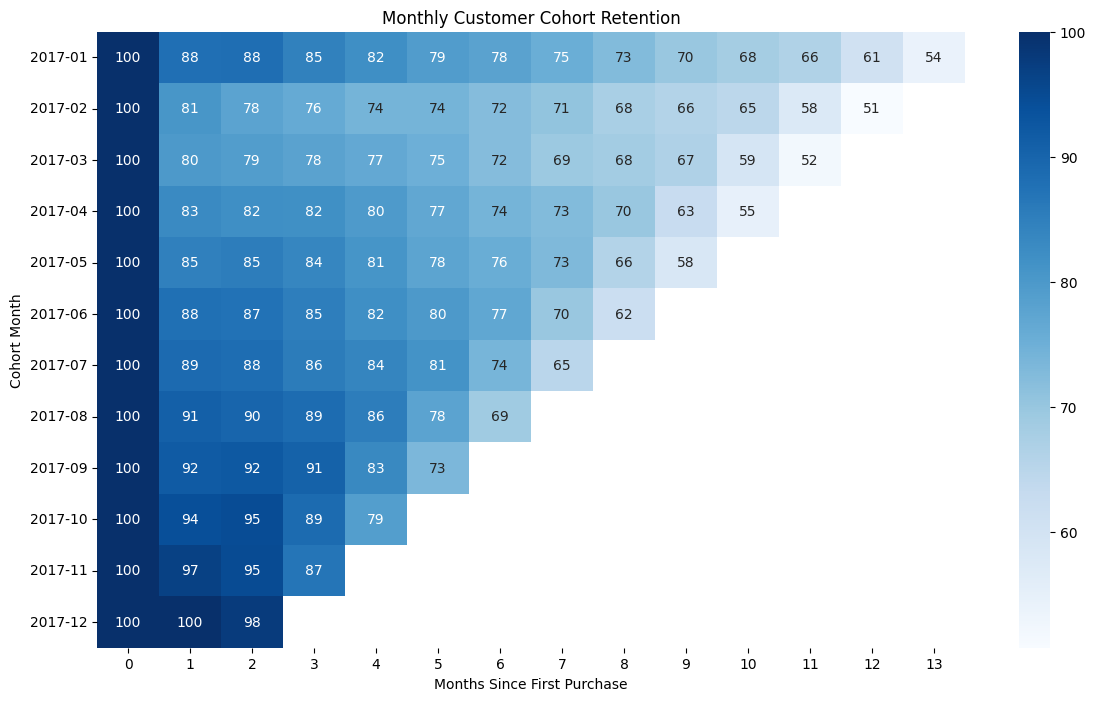

In [26]:
# 6. Visualize it as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Monthly Customer Cohort Retention')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.show()

In [27]:
# plotting the monthly dropoff
# Calculate month-over-month retention drop-off
dropoff_table = retention_table.diff(axis=1)

# Optional: remove the first column because there is no previous month
dropoff_table = dropoff_table.iloc[:, 1:]

print(dropoff_table.head())

month_number         1         2         3         4         5         6   \
cohort_month                                                                
2017-01      -12.030508  0.208663 -3.556267 -2.545330 -2.821449 -1.247482   
2017-02      -19.367794 -2.837155 -1.520059 -2.232586  0.012955 -1.878482   
2017-03      -20.094297 -0.768972 -1.251684 -1.307813 -1.588460 -2.767176   
2017-04      -17.116733 -0.950930 -0.121914 -2.060347 -2.962511 -2.743066   
2017-05      -15.138067  0.548570 -1.608728 -2.983235 -3.149655 -2.027860   

month_number        7         8         9         10        11        12  \
cohort_month                                                               
2017-01      -2.577709 -2.849331 -2.621780 -1.856382 -1.784429 -5.628508   
2017-02      -1.446647 -3.182623 -1.498467 -1.338688 -6.930950 -7.051863   
2017-03      -2.755950 -1.010328 -1.942075 -7.190166 -7.336102       NaN   
2017-04      -1.511734 -2.615056 -7.363609 -7.698872       NaN       NaN   
2017

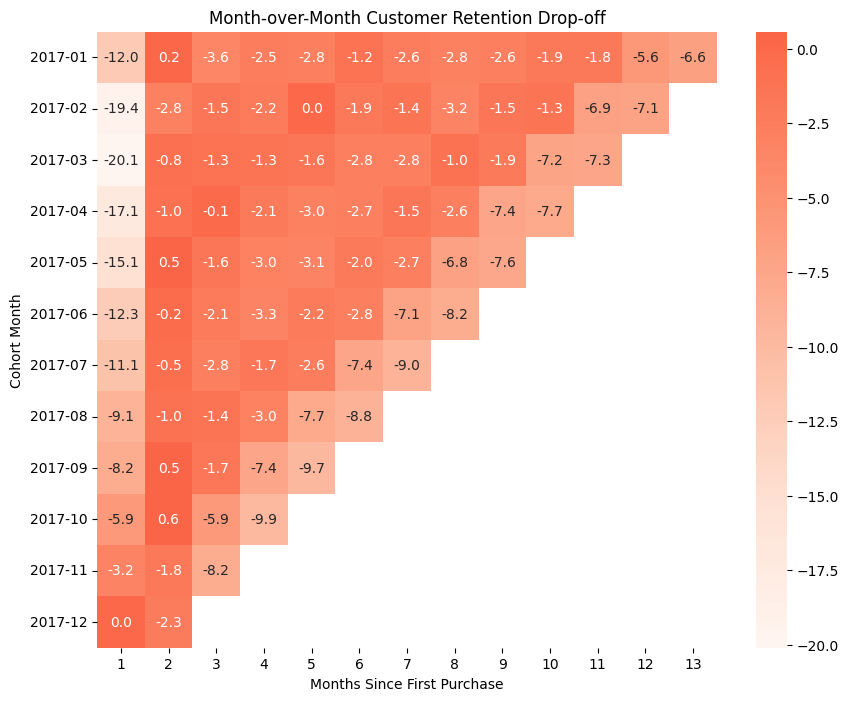

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    dropoff_table,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    center=0
)

plt.title('Month-over-Month Customer Retention Drop-off')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.show()

### see the dropoff by frequent customers

## Merchant concentration analysis

In [31]:
merchant_share = (
    historical
    .groupby(['card_id', 'merchant_id'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

In [32]:
merchant_share.head()

card_id          card_id          merchant_id    
C_ID_00007093c1  C_ID_00007093c1  M_ID_0379adb435    0.026846
                                  M_ID_06a8d84366    0.006711
                                  M_ID_0dabc5a70c    0.013423
                                  M_ID_109e9d2b1d    0.013423
                                  M_ID_15446e939c    0.026846
dtype: float64

In [33]:
print('Earliest date:', new['purchase_date'].min())
print('Latest date:', new['purchase_date'].max())

Earliest date: 2017-03-01 03:24:51
Latest date: 2018-04-30 23:59:59


In [34]:
merchants.head()

,merchant_id,merchant_group_id,merchant_category_id,subsector_id,numerical_1,numerical_2,category_1,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,...,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,category_4,city_id,state_id,category_2
0,M_ID_838061e48c,8353,792,9,-0.057471,-0.057471,N,E,E,-0.40,...,-2.25,18.666667,6,-2.32,13.916667,12,N,242,9,1.0
1,M_ID_9339d880ad,3184,840,20,-0.057471,-0.057471,N,E,E,-0.72,...,-0.74,1.291667,6,-0.57,1.687500,12,N,22,16,1.0
2,M_ID_e726bbae1e,447,690,1,-0.057471,-0.057471,N,E,E,-82.13,...,-82.13,260.000000,2,-82.13,260.000000,2,N,-1,5,5.0
3,M_ID_a70e9c5f81,5026,792,9,-0.057471,-0.057471,Y,E,E,NaN,...,NaN,4.666667,6,NaN,3.833333,12,Y,-1,-1,NaN
4,M_ID_64456c37ce,2228,222,21,-0.057471,-0.057471,Y,E,E,NaN,...,NaN,0.361111,6,NaN,0.347222,12,Y,-1,-1,NaN
